In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


In [2]:
import pandas as pd
import os 


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)



print(df.shape)
df.head()
print(df.columns)

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv
(6335, 4)
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


In [3]:
df = df.drop_duplicates(
    subset=["text"]
)

print(df.shape)

(6060, 4)


In [4]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


In [5]:
print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 4242
Validation: 909
Test: 909


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

In [7]:
X_train = tfidf.fit_transform(
    X_train_text
)

X_val = tfidf.transform(
    X_val_text
)

X_test = tfidf.transform(
    X_test_text
)

In [8]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4242, 30000)
(909, 30000)
(909, 30000)


In [9]:
from sklearn.linear_model import PassiveAggressiveClassifier

pac = PassiveAggressiveClassifier(
    C=1.0,
    max_iter=1000,
    random_state=42
)

pac.fit(
    X_train,
    y_train
)

PassiveAggressiveClassifier(random_state=42)

In [10]:
from sklearn.metrics import accuracy_score

val_pred = pac.predict(
    X_val
)

val_acc = accuracy_score(
    y_val,
    val_pred
)

print(
    "Validation Accuracy:",
    val_acc
)

Validation Accuracy: 0.9405940594059405


In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

test_pred = pac.predict(
    X_test
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print(
    "Test Accuracy:",
    test_acc
)

print(
    classification_report(
        y_test,
        test_pred
    )
)

Test Accuracy: 0.9504950495049505
              precision    recall  f1-score   support

        FAKE       0.94      0.96      0.95       461
        REAL       0.96      0.94      0.95       448

    accuracy                           0.95       909
   macro avg       0.95      0.95      0.95       909
weighted avg       0.95      0.95      0.95       909



In [12]:
from sklearn.metrics import roc_auc_score

scores = pac.decision_function(
    X_test
)

auc = roc_auc_score(
    y_test,
    scores
)

print(
    "ROC-AUC:",
    auc
)

ROC-AUC: 0.9895849473194919


In [13]:
import joblib

joblib.dump(
    pac,
    "passive_aggressive_final.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer_final.pkl"
)

print("Saved")

Saved


In [14]:
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score

c_values = [
    0.01,
    0.1,
    1,
    5,
    10
]

for c in c_values:

    model = PassiveAggressiveClassifier(
        C=c,
        max_iter=3000,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_val
    )

    acc = accuracy_score(
        y_val,
        pred
    )

    print(
        "C =",
        c,
        "Validation Accuracy =",
        acc
    )

C = 0.01 Validation Accuracy = 0.9372937293729373
C = 0.1 Validation Accuracy = 0.9416941694169417
C = 1 Validation Accuracy = 0.9405940594059405
C = 5 Validation Accuracy = 0.9394939493949395
C = 10 Validation Accuracy = 0.9394939493949395


In [15]:
pac_best = PassiveAggressiveClassifier(
    C=0.1,
    max_iter=3000,
    random_state=42
)

pac_best.fit(
    X_train,
    y_train
)

PassiveAggressiveClassifier(C=0.1, max_iter=3000, random_state=42)

In [16]:
from sklearn.metrics import accuracy_score

val_pred = pac_best.predict(
    X_val
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

Validation Accuracy: 0.9416941694169417


In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

final_pred = pac_best.predict(
    X_test
)

final_acc = accuracy_score(
    y_test,
    final_pred
)

print(
    "Final Test Accuracy:",
    final_acc
)

print(
    classification_report(
        y_test,
        final_pred
    )
)

Final Test Accuracy: 0.9471947194719472
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       461
        REAL       0.95      0.94      0.95       448

    accuracy                           0.95       909
   macro avg       0.95      0.95      0.95       909
weighted avg       0.95      0.95      0.95       909



In [18]:
from sklearn.metrics import roc_auc_score

scores = pac_best.decision_function(
    X_test
)

final_auc = roc_auc_score(
    y_test,
    scores
)

print(
    "Final ROC-AUC:",
    final_auc
)

Final ROC-AUC: 0.9894445305237062


In [19]:
X_combined = (
    df["title"].fillna("")
    + " [SEP] "
    + df["text"].fillna("")
)

y = df["label"]

In [20]:
from sklearn.model_selection import train_test_split

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_combined,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_title = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    max_features=30000
)

In [22]:
X_train = tfidf_title.fit_transform(
    X_train_text
)

X_val = tfidf_title.transform(
    X_val_text
)

X_test = tfidf_title.transform(
    X_test_text
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4242, 30000)
(909, 30000)
(909, 30000)


In [23]:
from sklearn.linear_model import PassiveAggressiveClassifier

pac_title = PassiveAggressiveClassifier(
    C=1,
    max_iter=1000,
    random_state=42
)

pac_title.fit(
    X_train,
    y_train
)

PassiveAggressiveClassifier(C=1, random_state=42)

In [24]:
from sklearn.metrics import accuracy_score

pred = pac_title.predict(
    X_val
)

val_acc = accuracy_score(
    y_val,
    pred
)

print(
    "Validation Accuracy:",
    val_acc
)

Validation Accuracy: 0.9416941694169417


In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred_test = pac_title.predict(
    X_test
)

acc = accuracy_score(
    y_test,
    pred_test
)

print(
    "Test Accuracy:",
    acc
)

print(
    classification_report(
        y_test,
        pred_test
    )
)

Test Accuracy: 0.9482948294829483
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       461
        REAL       0.95      0.94      0.95       448

    accuracy                           0.95       909
   macro avg       0.95      0.95      0.95       909
weighted avg       0.95      0.95      0.95       909



In [26]:
from sklearn.metrics import roc_auc_score

scores = pac_title.decision_function(
    X_test
)

auc = roc_auc_score(
    y_test,
    scores
)

print(
    "ROC-AUC:",
    auc
)

ROC-AUC: 0.9911876355748372


In [27]:
X = df["text"]

y = df["label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [29]:
print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 4242
Validation: 909
Test: 909


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_new = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,3),
    max_df=0.90,
    min_df=2,
    sublinear_tf=True,
    max_features=40000
)

In [31]:
X_train = tfidf_new.fit_transform(
    X_train_text
)

X_val = tfidf_new.transform(
    X_val_text
)

X_test = tfidf_new.transform(
    X_test_text
)

In [32]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4242, 40000)
(909, 40000)
(909, 40000)


In [33]:
from sklearn.linear_model import PassiveAggressiveClassifier

pac = PassiveAggressiveClassifier(
    C=1,
    max_iter=1000,
    random_state=42
)

pac.fit(
    X_train,
    y_train
)

PassiveAggressiveClassifier(C=1, random_state=42)

In [34]:
from sklearn.metrics import accuracy_score

pred = pac.predict(
    X_val
)

val_acc = accuracy_score(
    y_val,
    pred
)

print(
    "Validation Accuracy:",
    val_acc
)

Validation Accuracy: 0.944994499449945


In [35]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

test_pred = pac.predict(
    X_test
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print(
    "Test Accuracy:",
    test_acc
)

print(
    classification_report(
        y_test,
        test_pred
    )
)

Test Accuracy: 0.9504950495049505
              precision    recall  f1-score   support

        FAKE       0.95      0.95      0.95       461
        REAL       0.95      0.95      0.95       448

    accuracy                           0.95       909
   macro avg       0.95      0.95      0.95       909
weighted avg       0.95      0.95      0.95       909



In [36]:
from sklearn.metrics import roc_auc_score

scores = pac.decision_function(
    X_test
)

auc = roc_auc_score(
    y_test,
    scores
)

print(
    "ROC-AUC:",
    auc
)

ROC-AUC: 0.9903741865509761


In [37]:
import joblib

joblib.dump(
    pac,
    "pac_tfidf_trigram_40000.pkl"
)

joblib.dump(
    tfidf_new,
    "tfidf_trigram_40000.pkl"
)

print("Saved")

Saved


In [38]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(
    score_func=chi2,
    k=20000
)

X_train_fs = selector.fit_transform(
    X_train,
    y_train
)

X_val_fs = selector.transform(
    X_val
)

X_test_fs = selector.transform(
    X_test
)

In [39]:
print(X_train_fs.shape)
print(X_val_fs.shape)
print(X_test_fs.shape)

(4242, 20000)
(909, 20000)
(909, 20000)


In [40]:
from sklearn.linear_model import PassiveAggressiveClassifier

pac_fs = PassiveAggressiveClassifier(
    C=1,
    max_iter=1000,
    random_state=42
)

pac_fs.fit(
    X_train_fs,
    y_train
)

PassiveAggressiveClassifier(C=1, random_state=42)

In [41]:
from sklearn.metrics import accuracy_score

pred = pac_fs.predict(
    X_val_fs
)

val_acc = accuracy_score(
    y_val,
    pred
)

print(
    "Validation Accuracy:",
    val_acc
)

Validation Accuracy: 0.9504950495049505


In [42]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

test_pred = pac_fs.predict(
    X_test_fs
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print(
    "Test Accuracy:",
    test_acc
)

print(
    classification_report(
        y_test,
        test_pred
    )
)

Test Accuracy: 0.9438943894389439
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.94       461
        REAL       0.95      0.94      0.94       448

    accuracy                           0.94       909
   macro avg       0.94      0.94      0.94       909
weighted avg       0.94      0.94      0.94       909



In [43]:
from sklearn.metrics import roc_auc_score

scores = pac_fs.decision_function(
    X_test_fs
)

auc = roc_auc_score(
    y_test,
    scores
)

print(
    "ROC-AUC:",
    auc
)

ROC-AUC: 0.9882098311124884


In [44]:
test_pred = pac.predict(
    X_test
)

scores = pac.decision_function(
    X_test
)

In [45]:
import pandas as pd

errors = pd.DataFrame({
    "text": X_test_text.values,
    "actual": y_test.values,
    "predicted": test_pred,
    "confidence": abs(scores)
})

errors_only = errors[
    errors["actual"]
    !=
    errors["predicted"]
]

print(
    "Wrong Predictions:",
    len(errors_only)
)

Wrong Predictions: 45


In [46]:
errors_only[
    [
        "actual",
        "predicted",
        "confidence",
        "text"
    ]
].head(10)

,actual,predicted,confidence,text
0,REAL,FAKE,0.036133,"As they went on their rampage, the men who kil..."
53,FAKE,REAL,0.438250,Email HEALTHCARE REFORM TO MAKE AMERICA GREAT ...
99,FAKE,REAL,0.205994,0 comments GOP VP candidate Mike Pence’s Trump...
104,REAL,FAKE,1.041722,Darwin also didn’t have anything to say about ...
146,FAKE,REAL,0.124947,Politics Iranian Foreign Minister Mohammad Jav...
209,FAKE,REAL,0.422490,"“What difference, at this point, does it make?..."
211,FAKE,REAL,0.625389,0 comments \nMegyn Kelly seems to think that s...
224,FAKE,REAL,0.591768,There’s no clear consensus as of yet whether t...
227,FAKE,REAL,0.395735,\nAs if Hillary Clinton was not already facing...
248,REAL,FAKE,0.887277,"232 photos, 131 quotes and 43 numbers that tel..."


In [47]:
errors_only.sort_values(
    "confidence"
).head(10)

,text,actual,predicted,confidence
657,Does The U.S. Government Really Know Who Hack...,FAKE,REAL,0.023178
602,Desperate Obama RIPS Comey: 'We Don't Operate ...,FAKE,REAL,0.032492
0,"As they went on their rampage, the men who kil...",REAL,FAKE,0.036133
786,"Email \n\nBEVERLY HILLS, Calif. — More than 10...",FAKE,REAL,0.049697
539,Suspect captured in ‘ambush-style’ killings of...,FAKE,REAL,0.052503
839,Pinterest \nC.E. Dyer writes that the disaster...,FAKE,REAL,0.068696
582,The man accused of shooting a young woman dead...,REAL,FAKE,0.074481
716,As the attack on the U.S. consulate in Benghaz...,REAL,FAKE,0.075078
574,The chances of Donald Trump becoming the Repub...,REAL,FAKE,0.089644
503,"Citing an ""erosion of human rights guarantees""...",REAL,FAKE,0.094759


In [48]:
pd.crosstab(
    errors_only["actual"],
    errors_only["predicted"]
)

predicted,FAKE,REAL
actual,,
FAKE,0,21
REAL,24,0


In [49]:
scores = pac.decision_function(
    X_test
)

confidence = abs(
    scores
)

In [50]:
threshold = 0.10

final_pred = []

for s, p in zip(
    confidence,
    test_pred
):

    if s < threshold:
        final_pred.append(
            "UNCERTAIN"
        )

    else:
        final_pred.append(
            p
        )

In [51]:
import pandas as pd

pd.Series(
    final_pred
).value_counts()

FAKE         451
REAL         430
UNCERTAIN     28
Name: count, dtype: int64

In [52]:
mask = (
    pd.Series(final_pred)
    !=
    "UNCERTAIN"
)

conf_acc = (
    (
        pd.Series(final_pred)[mask]
        ==
        y_test.reset_index(drop=True)[mask]
    )
).mean()

print(
    "Confident Accuracy:",
    conf_acc
)

print(
    "Coverage:",
    mask.mean()
)

Confident Accuracy: 0.960272417707151
Coverage: 0.9691969196919692


In [53]:
import joblib

joblib.dump(
    pac,
    "/kaggle/working/pac_final.pkl"
)

joblib.dump(
    tfidf_new,
    "/kaggle/working/tfidf_final.pkl"
)

print("Done")

Done


# Grid SearchCV

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import PassiveAggressiveClassifier

param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2],
    'max_iter': [500, 1000, 2000],
    'loss': ['hinge', 'squared_hinge'],
    'fit_intercept': [True, False]
}

grid = GridSearchCV(
    PassiveAggressiveClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_fs, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=PassiveAggressiveClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1, 2],
                         'fit_intercept': [True, False],
                         'loss': ['hinge', 'squared_hinge'],
                         'max_iter': [500, 1000, 2000]},
             scoring='accuracy', verbose=2)

In [55]:
print("Best Parameters:")
print(grid.best_params_)

print("Best CV Accuracy:")
print(grid.best_score_)

Best Parameters:
{'C': 1, 'fit_intercept': True, 'loss': 'hinge', 'max_iter': 500}
Best CV Accuracy:
0.9526121185856835


In [56]:
best_model = grid.best_estimator_

In [57]:
from sklearn.metrics import accuracy_score

y_pred_grid = best_model.predict(X_test_fs)

print("Test Accuracy:", accuracy_score(y_test, y_pred_grid))

Test Accuracy: 0.9438943894389439


In [58]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_fs,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

CV Scores: [0.95995289 0.96466431 0.94457547 0.94693396 0.94693396]
Mean: 0.9526121185856835
Std: 0.00810200981280446


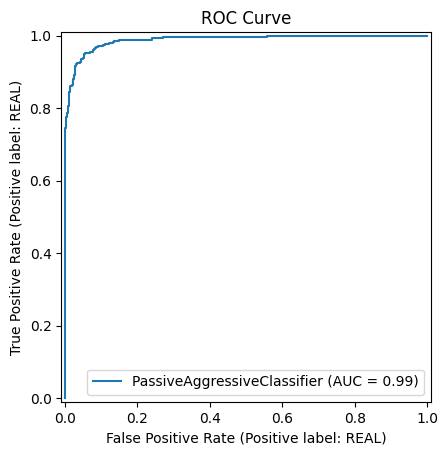

In [59]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    best_model,
    X_test_fs,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [60]:
from sklearn.metrics import roc_auc_score

scores = best_model.decision_function(X_test_fs)

auc = roc_auc_score(y_test, scores)

print("ROC AUC =", auc)

ROC AUC = 0.9882098311124884


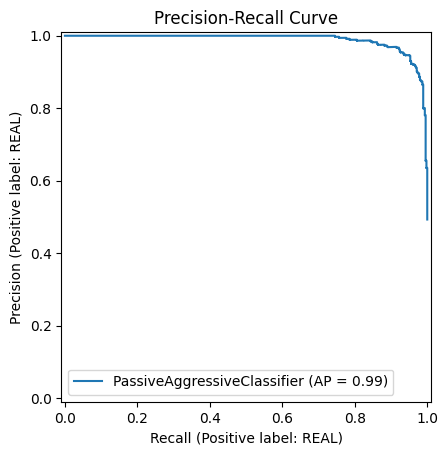

In [61]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test_fs,
    y_test
)

plt.title("Precision-Recall Curve")
plt.show()

In [62]:
print(type(tfidf))
print(type(selector))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.feature_selection._univariate_selection.SelectKBest'>


# Feature Importance Analysis 

In [63]:
import numpy as np
import pandas as pd

# Use the FINAL trained model
model = best_model   # change only if your final model variable has another name

# IMPORTANT:
# use the SAME vectorizer that created the training features
feature_names = tfidf_new.get_feature_names_out()

# If SelectKBest was used
if "selector" in globals():
    selected_idx = selector.get_support(indices=True)
    feature_names = feature_names[selected_idx]

# Model coefficients
coef = model.coef_[0]

# Top words for REAL
top_real = np.argsort(coef)[-20:]

# Top words for FAKE
top_fake = np.argsort(coef)[:20]

real_words = pd.DataFrame({
    "word": feature_names[top_real],
    "weight": coef[top_real]
}).sort_values("weight", ascending=False)

fake_words = pd.DataFrame({
    "word": feature_names[top_fake],
    "weight": coef[top_fake]
}).sort_values("weight")

print("\nTop words predicting REAL")
print(real_words)

print("\nTop words predicting FAKE")
print(fake_words)


Top words predicting REAL
            word    weight
19    candidates  3.343155
18          said  3.011559
17        friday  2.849657
16           cnn  2.411771
15           sen  2.258540
14           isn  2.234539
13      marriage  2.195575
12  conservative  2.183915
11       twitter  2.145086
10      fox news  2.123051
9   presidential  2.114162
8   clinton said  2.058421
7       recounts  2.026294
6     convention  2.020061
5           rush  1.987015
4         talked  1.975528
3          march  1.965590
2         parker  1.955444
1            gop  1.950663
0       coverage  1.943732

Top words predicting FAKE
             word    weight
0            2016 -5.258081
1         october -5.120051
2         article -4.176806
3        november -3.687087
4   november 2016 -3.657087
5        election -3.549371
6          source -3.542176
7           print -3.258239
8           share -3.202348
9          stated -3.112191
10          email -2.835051
11          mosul -2.808961
12           sn

In [64]:
[x for x in globals() if "test" in x.lower()]

['train_test_split',
 'X_test_text',
 'y_test',
 'X_test',
 'test_pred',
 'test_acc',
 'pred_test',
 'X_test_fs']

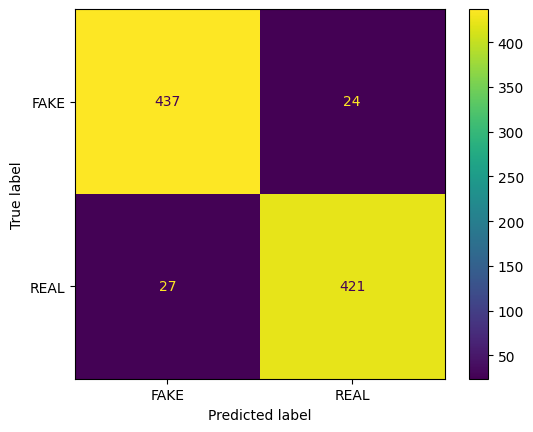


Confusion Matrix:
[[437  24]
 [ 27 421]]


In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_pred = best_model.predict(X_test_fs)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot()

plt.show()

print("\nConfusion Matrix:")
print(cm)

In [66]:
import pandas as pd

comparison = pd.DataFrame({

"Experiment":[
"PAC Baseline",
"PAC Tuned (C)",
"Title + Text",
"TFIDF 40k",
"Feature Selection",
"Grid Search + Final"
],

"Test Accuracy":[
95.05,
94.72,
94.83,
95.05,
94.39,
94.39
],

"ROC-AUC":[
0.9896,
0.9894,
0.9912,
0.9904,
0.9882,
0.9882
]

})

comparison = comparison.sort_values(
by="Test Accuracy",
ascending=False
)

print(comparison)

            Experiment  Test Accuracy  ROC-AUC
0         PAC Baseline          95.05   0.9896
3            TFIDF 40k          95.05   0.9904
2         Title + Text          94.83   0.9912
1        PAC Tuned (C)          94.72   0.9894
4    Feature Selection          94.39   0.9882
5  Grid Search + Final          94.39   0.9882


In [67]:
import joblib


joblib.dump(
    best_model,
    "fake_news_model.pkl"
)


joblib.dump(
    tfidf_new,
    "tfidf_vectorizer.pkl"
)


if "selector" in globals():
    joblib.dump(
        selector,
        "feature_selector.pkl"
    )

print("Saved successfully")

Saved successfully


In [68]:
import os

print(os.listdir())

['fake_news_model.pkl', '__notebook__.ipynb', 'feature_selector.pkl', 'tfidf_vectorizer.pkl', 'tfidf_trigram_40000.pkl', 'tfidf_final.pkl', 'pac_final.pkl', 'tfidf_vectorizer_final.pkl', 'pac_tfidf_trigram_40000.pkl', 'passive_aggressive_final.pkl']


In [69]:
import joblib

loaded_model = joblib.load(
    "fake_news_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.linear_model._passive_aggressive.PassiveAggressiveClassifier'>
